## 1. Gathering data:

In [1]:
# Importing intial libraries to begin working wtih data
import pandas as pd
import numpy as np

In [2]:
# Reading data in
data = pd.read_csv('realtor-data.zip.csv')
data.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


# 2. Prepare data:

In [3]:
# Let's see where there are NaN values in our dataset
data.isnull().sum()

brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64

In [4]:
# Since our dataset is around 2.2m+ rows of data, we can drop these,
# as we will likely have ample data to train and test with
data.dropna(inplace=True)
data.info()

# We have ~1,000,000 rows of data remaining

<class 'pandas.core.frame.DataFrame'>
Index: 1084909 entries, 502 to 2226381
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   brokered_by     1084909 non-null  float64
 1   status          1084909 non-null  object 
 2   price           1084909 non-null  float64
 3   bed             1084909 non-null  float64
 4   bath            1084909 non-null  float64
 5   acre_lot        1084909 non-null  float64
 6   street          1084909 non-null  float64
 7   city            1084909 non-null  object 
 8   state           1084909 non-null  object 
 9   zip_code        1084909 non-null  float64
 10  house_size      1084909 non-null  float64
 11  prev_sold_date  1084909 non-null  object 
dtypes: float64(8), object(4)
memory usage: 107.6+ MB


In [5]:
# Now checking for duplicates
data.duplicated().sum()

# No duplicates; each row of data is unique

0

In [6]:
# Categorical data:
# It is likely that brokered_by, street, city, state, and zip_code are all categorical.
# Let's see how many unique categories there are of each
print(f'''{data['brokered_by'].nunique()} unique categories of brokered_by''')
print(f'''{data['street'].nunique()} unique categories of street''')
print(f'''{data['city'].nunique()} unique categories of city''')
print(f'''{data['state'].nunique()} unique categories of state''')
print(f'''{data['zip_code'].nunique()} unique categories of zip_code''')

# There are too many categories for street, city, and zip_code, so we will not encode them
# Since there are approximately as many unique streets as entries (~1,000,000 each), we can drop street
# We can also drop brokered_by, status, street as it provides no information to housing pricing
# Since we already have cities, we can drop zip_code
data.drop(columns=['brokered_by', 'status', 'street', 'zip_code'], inplace=True)

82809 unique categories of brokered_by
1003765 unique categories of street
15103 unique categories of city
53 unique categories of state
24855 unique categories of zip_code


In [7]:
# Since we don't want any of the states to have a bias, we will use One-Hot Encoding
# to create 53 dummy variables
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
state_dummies = ohe.fit_transform(data[['state']])
state_dummies = pd.DataFrame(state_dummies, columns=ohe.get_feature_names_out())

In [8]:
# We can now join this back into our data and drop our initial 'state' column
data = data.reset_index(drop=True)
state_dummies = state_dummies.reset_index(drop=True)

data = data.join(state_dummies)
data.drop(columns='state', inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1084909 entries, 0 to 1084908
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   price                       1084909 non-null  float64
 1   bed                         1084909 non-null  float64
 2   bath                        1084909 non-null  float64
 3   acre_lot                    1084909 non-null  float64
 4   city                        1084909 non-null  object 
 5   house_size                  1084909 non-null  float64
 6   prev_sold_date              1084909 non-null  object 
 7   state_Alabama               1084909 non-null  float64
 8   state_Alaska                1084909 non-null  float64
 9   state_Arizona               1084909 non-null  float64
 10  state_Arkansas              1084909 non-null  float64
 11  state_California            1084909 non-null  float64
 12  state_Colorado              1084909 non-null  float64
 1

In [9]:
# We should seperate our prev_sold_date into year, month, day
data['prev_sold_date'] = pd.to_datetime(data['prev_sold_date'])
data['prev_sold_year'] = data['prev_sold_date'].dt.year
data['prev_sold_month'] = data['prev_sold_date'].dt.month
data['prev_sold_day'] = data['prev_sold_date'].dt.day

data.drop(columns='prev_sold_date', inplace=True)

In [10]:
# Now we can find outliers in our data based on our numerical values (price, bed, bath, acre_lot, house_size)
# We will also look for outliers in the year
x = data[['price', 'bed', 'bath', 'acre_lot', 'house_size', 'prev_sold_year']]
mean = x.mean()
sd = x.std()

outliers = (x < mean-3*sd) | (x > mean+3*sd)

filtered_data = data[(outliers.any(axis=1))]
data.drop(filtered_data.index, inplace=True)

In [11]:
# Instead of using standard K-folds, we will use Repeated K-folds
# with k = 10 and 10 repeats for better model performance
from sklearn.model_selection import RepeatedKFold
rkf = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)

In [12]:
# Splitting our dataset into our train and test sets
for train_index, test_index in rkf.split(data):
    X_train, X_test = data.drop(columns=['price']).iloc[train_index], data.drop(columns=['price']).iloc[test_index]
    y_train, y_test = data['price'].iloc[train_index], data['price'].iloc[test_index]

In [13]:
# Since we have a lot of unique cities in our dataset (~15,000), we should use
# target encoding to encode without bias
# !pip install category_encoders
from category_encoders import TargetEncoder
te = TargetEncoder(cols=['city'])
X_train = te.fit_transform(X_train, y_train)
X_test = te.transform(X_test)

# 3. Visualizing data:

In [14]:
# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

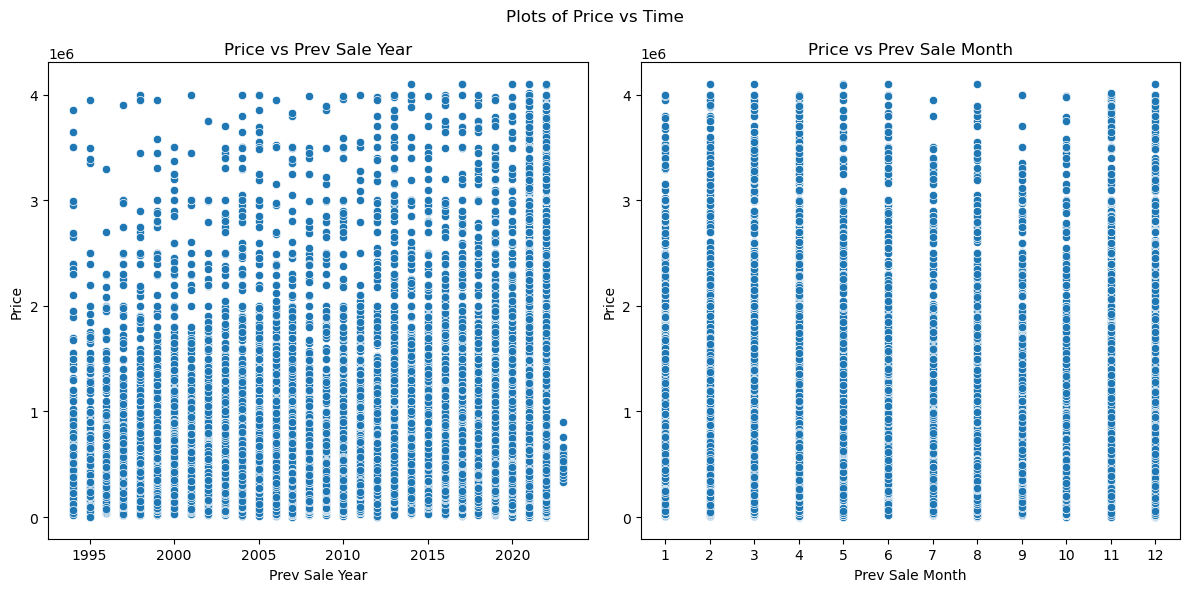

In [15]:
# Using the test data to avoid long computation times
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Plots of Price vs Time')

# Scatterplot of price vs time (year)
sns.scatterplot(x=X_test['prev_sold_year'], y=y_test, ax=axes[0])
axes[0].set_title('Price vs Prev Sale Year')
axes[0].set_xlabel('Prev Sale Year')
axes[0].set_ylabel('Price')

# Scatterplot of price vs time (month)
sns.scatterplot(x=X_test['prev_sold_month'], y=y_test, ax=axes[1])
axes[1].set_title('Price vs Prev Sale Month')
axes[1].set_xlabel('Prev Sale Month')
axes[1].set_ylabel('Price')
axes[1].set_xticks(range(1, 13))


plt.tight_layout()
plt.show()

# We can see data is distributed mostly evenly, with most recent years having higher prices

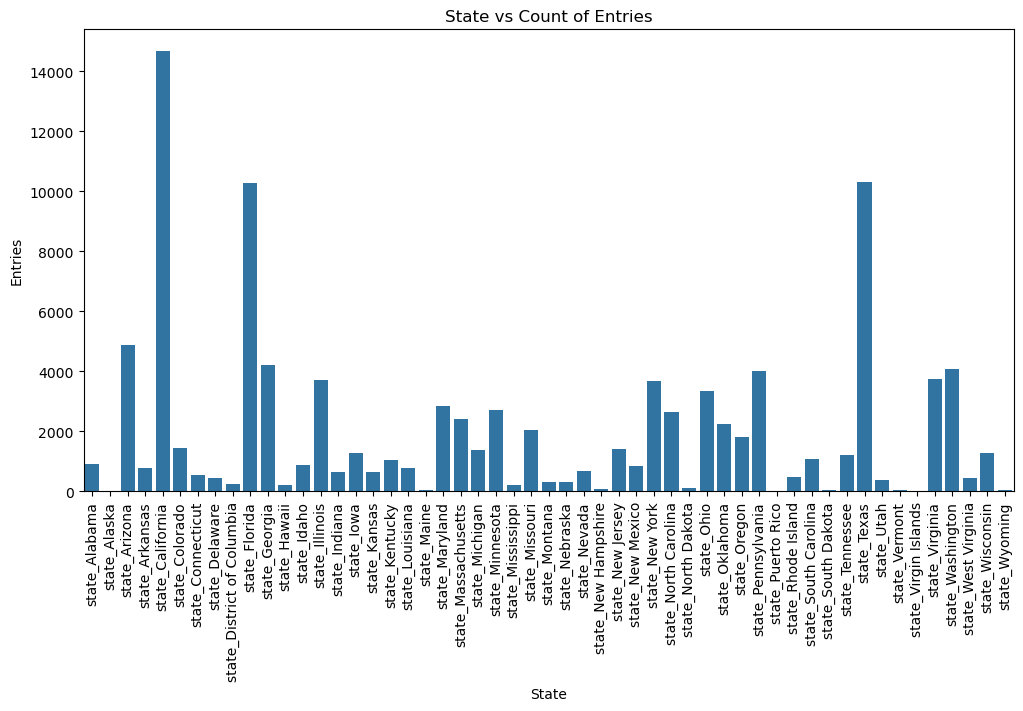

In [16]:
# Categorical plot of entries by state (once again using test set for computational purposes)
states = X_test.loc[:,'state_Alabama':'state_Wyoming']

plt.figure(figsize=(12, 6))
plt.title('State vs Count of Entries')
sns.barplot(x=states.columns, y=states.sum())
plt.xlabel('State')
plt.ylabel('Entries')
plt.tick_params(axis='x', rotation=90)
plt.show()

# 4. Model selection and training:

We are going to be using 4 main models:
1. Linear Regression
2. Random Forest
3. Random Forest w/ Boosting
4. Support Vector Machine (SVM)

In [17]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Making a pipeline
pipelinereg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipelinereg.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# We used GridSearchCV to find the best parameters for our Random Forest model: max_depth = 10, n_estimators = 200

# # Fine tuning parameters via parameter grid
# param_grid = {
#     'model__max_depth': [5,10],
#     'model__n_estimators': [100, 200]
# }

# # Create a pipeline
# pipelineforest = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', RandomForestRegressor(n_jobs = -1, verbose = 2))
# ])

# # Create GridSearch object
# grid_search = GridSearchCV(estimator=pipelineforest, param_grid=param_grid, cv=2, scoring='neg_mean_absolute_error')

# # Fit the grid search to the data
# grid_search.fit(X_train, y_train)

# # Obtain best model from GridSearchCV
# grid_search.best_params_

In [19]:
# Random Forest Regressor
pipelineforest = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1, verbose=1))
])
pipelineforest.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   22.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.5min finished


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=200,
                                       n_jobs=-1, verbose=1))])

In [20]:
# Random Forest with Boosting

import xgboost as xgb

# Define parameters correctly
params = {
    "max_depth": 10,
    "n_estimators": 200,
    "n_jobs": -1,
    "verbosity": 1,
    "objective": "reg:squarederror"  # Define objective for regression
}

# Convert data to DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Train the model using xgb.train
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    early_stopping_rounds=10,
    evals=[(dtrain, "train"), (dtest, "eval")],  # Specify validation sets
    verbose_eval=True
)


c:\Users\vishv\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:10:54] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	train-rmse:358074.61340	eval-rmse:359081.51385
[1]	train-rmse:300877.67588	eval-rmse:304087.87245
[2]	train-rmse:266445.89370	eval-rmse:271513.34935
[3]	train-rmse:245570.82117	eval-rmse:252245.94517
[4]	train-rmse:233287.14845	eval-rmse:241391.36873
[5]	train-rmse:225474.75497	eval-rmse:234630.62403
[6]	train-rmse:220684.92997	eval-rmse:230593.23377
[7]	train-rmse:216952.45159	eval-rmse:227790.06549
[8]	train-rmse:214589.91486	eval-rmse:225887.12059
[9]	train-rmse:212875.47725	eval-rmse:224592.70579
[10]	train-rmse:211097.02651	eval-rmse:223597.39899
[11]	train-rmse:209502.28585	eval-rmse:222552.77168
[12]	train-rmse:208347.46681	eval-rmse:221790.22145
[13]	train-rmse:207638.09477	eval-rmse:221308.85413
[14]	train-rmse:206782.54219	eval-rmse:220808.08251
[15]	train-rmse:206134.30048	eval-rmse:220385.64816
[16]	train-rmse:205626.37553	eval-rmse:220031.95623
[17]	train-rmse:204952.52587	eval-rmse:219804.79140
[18]	train-rmse:204315.17469	eval-rmse:219348.68188
[19]	train-rmse:203441

In [21]:
# Support Vector Machine
from sklearn.svm import LinearSVR

svmpipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVR())
])

svmpipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearSVR())])

# 5. Model evaluation

In [22]:
# Now we can evaluate our models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

# Function to evaluate models
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    return mae, rmse, r2, mape

In [23]:
# Evaluate Linear Regression
mae_lr, rmse_lr, r2_lr, mape_lr = evaluate_model(pipelinereg, X_test, y_test)
print(f'Linear Regression - MAE: {mae_lr}, RMSE: {rmse_lr}, R2: {r2_lr}, MAPE: {mape_lr}')

Linear Regression - MAE: 155877.93550822831, RMSE: 264870.68963586225, R2: 0.6519312367035683, MAPE: 22.18597274770841


In [24]:
# Evaluate Random Forest
mae_rf, rmse_rf, r2_rf, mape_rf = evaluate_model(pipelineforest, X_test, y_test)
print(f'Random Forest - MAE: {mae_rf}, RMSE: {rmse_rf}, R2: {r2_rf}, MAPE: {mape_rf}')

Random Forest - MAE: 131382.2770310616, RMSE: 235579.65363293685, R2: 0.7246577839717383, MAPE: 24.33761513831309


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished


In [25]:
# Evaluate Random Forest with Boosting

# Needs to be evaluated differently since we used xgb.train
y_pred_xgb = model.predict(dtest)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
print(f'XGBoost - MAE: {mae_xgb}, RMSE: {rmse_xgb}, R2: {r2_xgb}, MAPE: {mape_xgb}')

XGBoost - MAE: 109538.63968606401, RMSE: 208527.33509240948, R2: 0.7842636971284951, MAPE: 23.021800982275465


In [26]:
# Evaluate Support Vector Machine
mae_svm, rmse_svm, r2_svm, mape_svm = evaluate_model(svmpipeline, X_test, y_test)
print(f'Support Vector Machine - MAE: {mae_svm}, RMSE: {rmse_svm}, R2: {r2_svm}, MAPE: {mape_svm}')

Support Vector Machine - MAE: 164538.6189386194, RMSE: 339636.42229823576, R2: 0.42769734535201254, MAPE: 17.67780191096896
